In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB, MultinomialNB

import tensorflow as tf

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## --- 1. Load Data ---

In [155]:
df = pd.read_csv('normalized_labeled_data.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.head())

Initial dataset shape: (8411, 26)
   index  EventType             EventDate  HasSafetyRec  Mode  \
0      0          1  2020-12-31T18:15:00Z         False     0   
1      1          0  2020-12-31T18:00:00Z         False     0   
2      2          0  2020-12-31T15:45:00Z         False     0   
3      3          0  2020-12-31T14:49:00Z         False     0   
4      4          1  2020-12-31T02:15:00Z         False     0   

  OriginalPublishedDate HighestInjuryLevel FatalInjuryCount  \
0        12/2/2022 0:00                  ?              0.0   
1        9/20/2021 0:00                  ?              0.0   
2       10/19/2021 0:00              Minor              0.0   
3                     ?                  ?              0.0   
4                     ?                  ?                ?   

  SeriousInjuryCount MinorInjuryCount OnboardInjuryCount  Make  Model  \
0                0.0              0.0                0.0   250    303   
1                0.0              0.0             

## --- 2. Initial Inspection and Pre-Processing ---

In [156]:
# Handle '?' and Empty Strings
df.replace('?', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)


In [157]:
# Drop Unnecessary Columns
df.drop('index', axis=1, inplace=True)
df.drop('OriginalPublishedDate', axis=1, inplace=True)


In [158]:
print(df['HighestInjuryLevel'].value_counts(dropna=False))


HighestInjuryLevel
NaN        4861
Fatal      1578
Minor      1074
Serious     898
Name: count, dtype: int64


In [159]:
# Define Target Variable and Handle Data Leakage
TARGET_COLUMN = 'FatalYN'
leaky_features = [
    'HighestInjuryLevel', 'FatalInjuryCount', 'SeriousInjuryCount',
    'MinorInjuryCount', 'OnboardInjuryCount'
]

existing_leaky_features = [col for col in leaky_features if col in df.columns]
df.drop(columns=existing_leaky_features, inplace=True, errors='ignore')


In [160]:
# Feature Engineering
df['EventDate'] = pd.to_datetime(df['EventDate'], errors='coerce')
df['EventYear'] = df['EventDate'].dt.year
df['EventMonth'] = df['EventDate'].dt.month
df['EventDay'] = df['EventDate'].dt.day
df['EventDayOfWeek'] = df['EventDate'].dt.dayofweek
df['EventHour'] = df['EventDate'].dt.hour
df.drop('EventDate', axis=1, inplace=True)

# Boolean Conversion
bool_cols_map = {'HasSafetyRec': {True: 1, False: 0}, 'AmateurBuilt': {True: 1, False: 0}}
for col, mapping in bool_cols_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

truly_numerical_features = ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'NumberOfEngines']

# Add HasSafetyRec and AmateurBuilt and scale them
truly_numerical_features.append('HasSafetyRec')
truly_numerical_features.append('AmateurBuilt')

truly_numerical_features = [col for col in truly_numerical_features if col in df.columns]

# All other features (that are not the target and not in truly_numerical_features) will be treated as categorical and converted to string for ordinal encoding.
all_features = df.drop(TARGET_COLUMN, axis=1).columns.tolist()
features_to_make_categorical_str = [
    col for col in all_features if col not in truly_numerical_features
]

print(f"Features to be treated as numeric (for scaling): {truly_numerical_features}")
print(f"Features to be converted to string and ordinal encoded: {features_to_make_categorical_str}")

for col in features_to_make_categorical_str:
    if col in df.columns:
        df[col] = df[col].astype(str) # Convert to string to ensure ordinal encoding
print(df.head())

Features to be treated as numeric (for scaling): ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'NumberOfEngines', 'HasSafetyRec', 'AmateurBuilt']
Features to be converted to string and ordinal encoded: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']
  EventType  HasSafetyRec Mode Make Model AirCraftCategory AirportID  \
0         1             0    0  250   303                1      2165   
1         0             0    0  896  1577                1      2277   
2         0             0    0  250    75                1       390   
3         0             0    0  157   121                1      1488   
4         1             0    0   45   514                1       752   

   AmateurBuilt  NumberOfEngines EngineType PurposeOfFlight FAR  \
0             0            0.250          6              15  

In [ ]:
tot = 0
for index, col in df.iterrows():
    if col['FatalYN'] == 1 and col['EventYear'] == 2021:
        tot+=1
print(tot)



321


## --- Final Data Checks and Target Preparation ---

In [161]:
print("df.info() after type conversions:")
df.info()
print("\ndf.head() after type conversions:")
print(df.head())

# Drop rows where target is NaN
df.dropna(subset=[TARGET_COLUMN], inplace=True)
# Ensure target is integer
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

print(f"\nShape after dropping rows with NaN in target: {df.shape}")
print(f"Target '{TARGET_COLUMN}' value counts:\n{df[TARGET_COLUMN].value_counts(normalize=True)}")

df.info() after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8411 entries, 0 to 8410
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EventType             8411 non-null   object 
 1   HasSafetyRec          8411 non-null   int64  
 2   Mode                  8411 non-null   object 
 3   Make                  8411 non-null   object 
 4   Model                 8411 non-null   object 
 5   AirCraftCategory      8411 non-null   object 
 6   AirportID             8411 non-null   object 
 7   AmateurBuilt          8411 non-null   int64  
 8   NumberOfEngines       6677 non-null   float64
 9   EngineType            8411 non-null   object 
 10  PurposeOfFlight       8411 non-null   object 
 11  FAR                   8411 non-null   object 
 12  AirCraftDamage        8411 non-null   object 
 13  WeatherCondition      8411 non-null   object 
 14  BroadPhaseofFlight    8411 non-null   

## EDA Visualizations

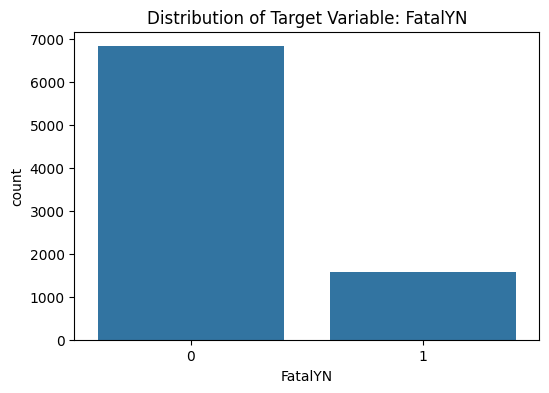

In [105]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title(f'Distribution of Target Variable: {TARGET_COLUMN}')
plt.show()

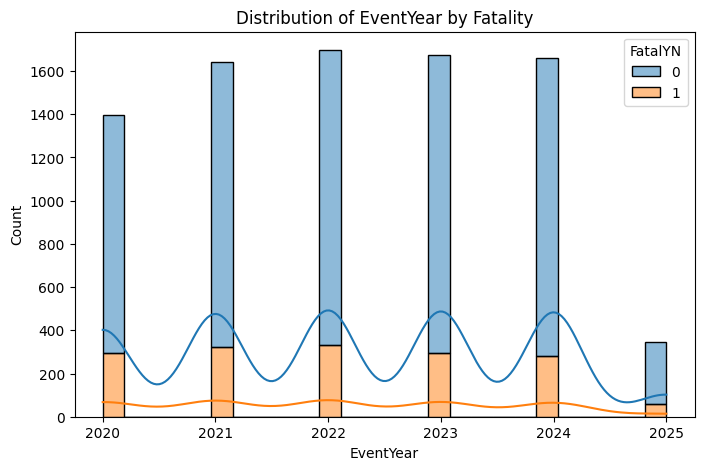

In [18]:
# Distribution of a numerical feature (EventYear)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='EventYear', hue=TARGET_COLUMN, kde=True, multiple="stack")
plt.title('Distribution of EventYear by Fatality')
plt.show()

Counter({'3': 5895, '0': 2207, '1': 243, '2': 66})


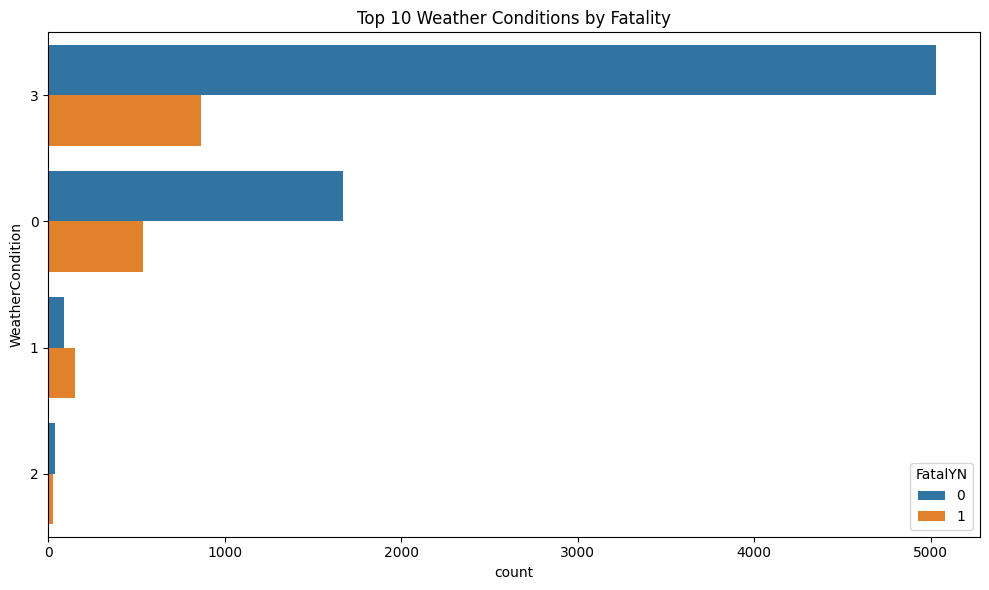

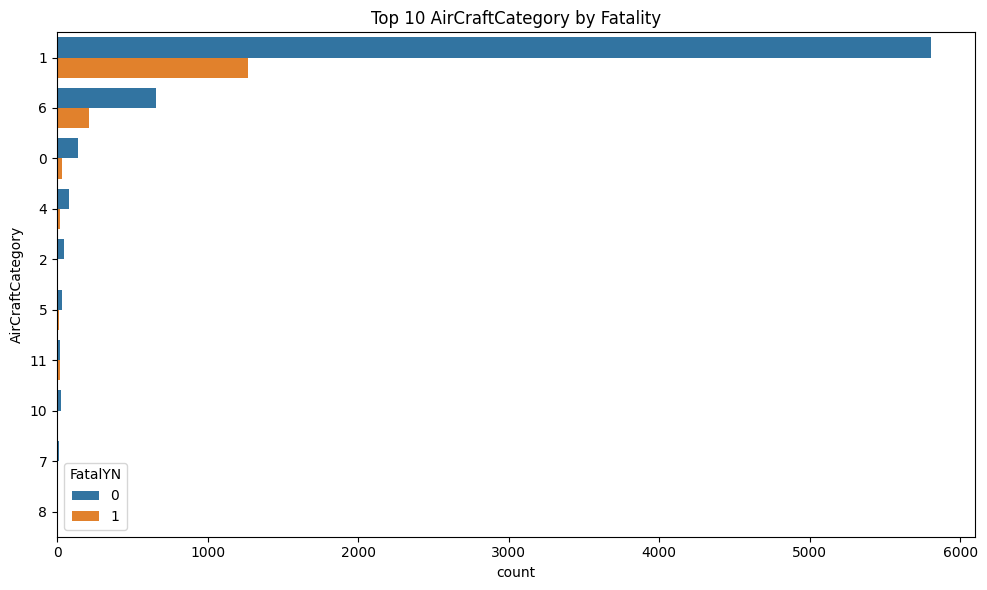

In [19]:
# Distribution of Catagorical Features
from collections import Counter 

print(Counter(df['WeatherCondition']))
top_n = 10
plt.figure(figsize=(10, 6))
top_categories = df['WeatherCondition'].value_counts().nlargest(top_n).index
sns.countplot(y='WeatherCondition', hue=TARGET_COLUMN, data=df[df['WeatherCondition'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} Weather Conditions by Fatality')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_categories = df['AirCraftCategory'].value_counts().nlargest(top_n).index
sns.countplot(y='AirCraftCategory', hue=TARGET_COLUMN, data=df[df['AirCraftCategory'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} AirCraftCategory by Fatality')
plt.tight_layout()
plt.show()

## --- Train-Test Split ---

In [162]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]



In [163]:
numerical_features_for_pipeline = [col for col in truly_numerical_features if col in X.columns]
categorical_features_for_pipeline = [col for col in features_to_make_categorical_str if col in X.columns]

print(f"Features for X: {X.columns.tolist()}")
print(f"Numerical features for pipeline: {numerical_features_for_pipeline}")
print(f"Categorical features for pipeline: {categorical_features_for_pipeline}")

Features for X: ['EventType', 'HasSafetyRec', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType', 'EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour']
Numerical features for pipeline: ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'NumberOfEngines', 'HasSafetyRec', 'AmateurBuilt']
Categorical features for pipeline: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']


In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(X_train.columns)


X_train shape: (6728, 22), X_test shape: (1683, 22)
y_train distribution:
FatalYN
0    0.812426
1    0.187574
Name: proportion, dtype: float64
y_test distribution:
FatalYN
0    0.81224
1    0.18776
Name: proportion, dtype: float64
Index(['EventType', 'HasSafetyRec', 'Mode', 'Make', 'Model',
       'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines',
       'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage',
       'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus',
       'MostRecentReportType', 'EventYear', 'EventMonth', 'EventDay',
       'EventDayOfWeek', 'EventHour'],
      dtype='object')


## --- Categorical Encoding & Scaling ---

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
# Numerical pipeline

print(X_test.shape)
print(X_train.shape)
numerical_pipeline = Pipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='Missing')), # Use 'Missing' for clarity
    ('onehot', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=(-1)))
]) #  OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features_for_pipeline),
        ('cat', categorical_pipeline, categorical_features_for_pipeline)
    ],
    remainder='drop'
)



# Apply transformations
print("Fitting and transforming X_train")
X_train_processed = preprocessor.fit_transform(X_train)
print(X_train_processed)

# Get feature names after one-hot encoding for better interpretability

feature_names_out = preprocessor.get_feature_names_out()
print(f"Number of features after preprocessing: {len(feature_names_out)}")


print("Transforming X_test")
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

(1683, 22)
(6728, 22)
Fitting and transforming X_train
[[-0.79388841 -1.40008057 -0.64431178 ...  7.          0.
   3.        ]
 [-1.46812235  0.48035769 -0.30558365 ...  8.          1.
   2.        ]
 [ 0.55457946 -1.71348695  1.16223823 ...  9.          1.
   2.        ]
 ...
 [-1.46812235  1.42057683  0.71060073 ...  7.          0.
   3.        ]
 [ 0.55457946 -0.77326782  1.16223823 ... 10.          0.
   3.        ]
 [ 1.90304733 -0.77326782  0.3718726  ...  1.          2.
   0.        ]]
Number of features after preprocessing: 22
Transforming X_test
X_train_processed shape: (6728, 22)
X_test_processed shape: (1683, 22)


In [225]:
use_smote = True
print(use_smote)

True


## --- Oversample Minority Class for Class Imbalance using SMOTE ---

In [226]:
from imblearn.under_sampling import RandomUnderSampler
if use_smote and y_train.value_counts().min() >= 6:
    smote = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
    print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
    print(f"Distribution of y_train after SMOTE:\n{pd.Series(y_train_resampled).value_counts(normalize=True)}")
else:
    print("\nSMOTE failed due to insufficient samples")
    X_train_resampled, y_train_resampled = X_train_processed, y_train
    
print(X_test_processed.shape)

Shape of X_train after SMOTE: (2524, 22)
Distribution of y_train after SMOTE:
FatalYN
0    0.5
1    0.5
Name: proportion, dtype: float64
(1683, 22)


## --- Hyperparameter Tuning --- 

In [227]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Example stratified CV
cv =KFold(n_splits=5, shuffle=True, random_state=42)

# Placeholder for results
results = {}

# === 1. GaussianNB ===
gnb = GaussianNB()
param_gnb = {
    'var_smoothing': np.logspace(-9, -6, 10)
}
search_gnb = RandomizedSearchCV(gnb, param_distributions=param_gnb, scoring='roc_auc', cv=cv, n_iter=10)
search_gnb.fit(X_train_resampled, y_train_resampled)
results['GaussianNB'] = search_gnb

# === Display best parameters and scores ===
for name, model in results.items():
    print(f"\n{name}")
    print("Best ROC AUC Score:", model.best_score_)
    print("Best Parameters:", model.best_params_)


GaussianNB
Best ROC AUC Score: 0.772158765591693
Best Parameters: {'var_smoothing': np.float64(4.641588833612773e-08)}


## --- Naive Bayes Model Building and Training ---

In [229]:
best_score = results['GaussianNB'].best_params_['var_smoothing']

model = GaussianNB(priors=(.5, .5), var_smoothing=best_score)

model.fit(X_train_resampled, y_train_resampled)

GaussianNB(priors=(0.5, 0.5), var_smoothing=np.float64(4.641588833612773e-08))

## --- Model Evaluation ---


GaussianNB Classification Report:
               precision    recall  f1-score   support

Not Fatal (0)       0.91      0.74      0.82      1367
    Fatal (1)       0.38      0.70      0.49       316

     accuracy                           0.73      1683
    macro avg       0.65      0.72      0.66      1683
 weighted avg       0.81      0.73      0.76      1683



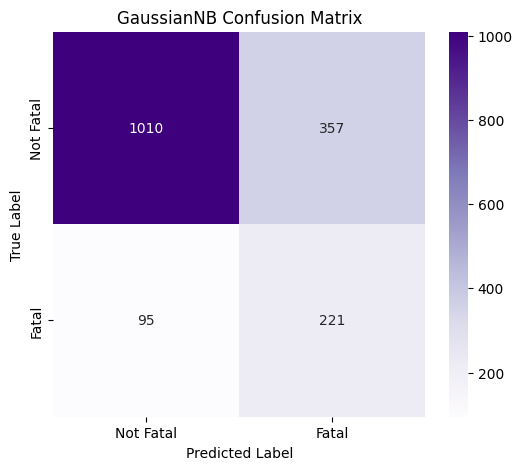


GaussianNB ROC AUC Score: 0.7800


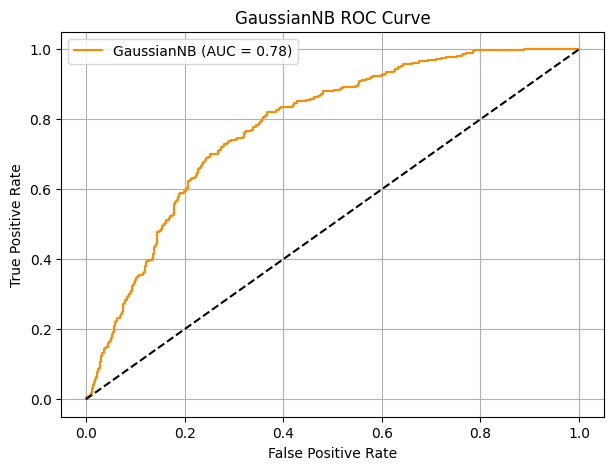

In [230]:
# Plot Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on test set
y_probs = model.predict_proba(X_test_processed)[:, 1]
y_preds = model.predict(X_test_processed)

# === Classification Report ===
print("\nGaussianNB Classification Report:")
print(classification_report(y_test, y_preds, target_names=['Not Fatal (0)', 'Fatal (1)']))

# === Confusion Matrix ===
cm_gnb = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples', xticklabels=['Not Fatal', 'Fatal'], yticklabels=['Not Fatal', 'Fatal'])
plt.title('GaussianNB Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# === ROC AUC Score ===
auc_gnb = roc_auc_score(y_test, y_probs)
print(f"\nGaussianNB ROC AUC Score: {auc_gnb:.4f}")

# === ROC Curve ===
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC = {auc_gnb:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GaussianNB ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [234]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import matplotlib.pyplot as plt

var_smoothing_list = np.logspace(-9, -6, 10)
accuracies = []
losses = []
aucs = []

for n in var_smoothing_list:
    tuningModel = GaussianNB(priors=(0.5, 0.5), var_smoothing=n)
    tuningModel.fit(X_train_resampled, y_train_resampled)
    y_pred = tuningModel.predict(X_test_processed)
    y_pred_proba = tuningModel.predict_proba(X_test_processed)

    accuracies.append(accuracy_score(y_test, y_pred))
    losses.append(log_loss(y_test, y_pred_proba))
    aucs.append(roc_auc_score(y_test, y_pred_proba[:, 1]))

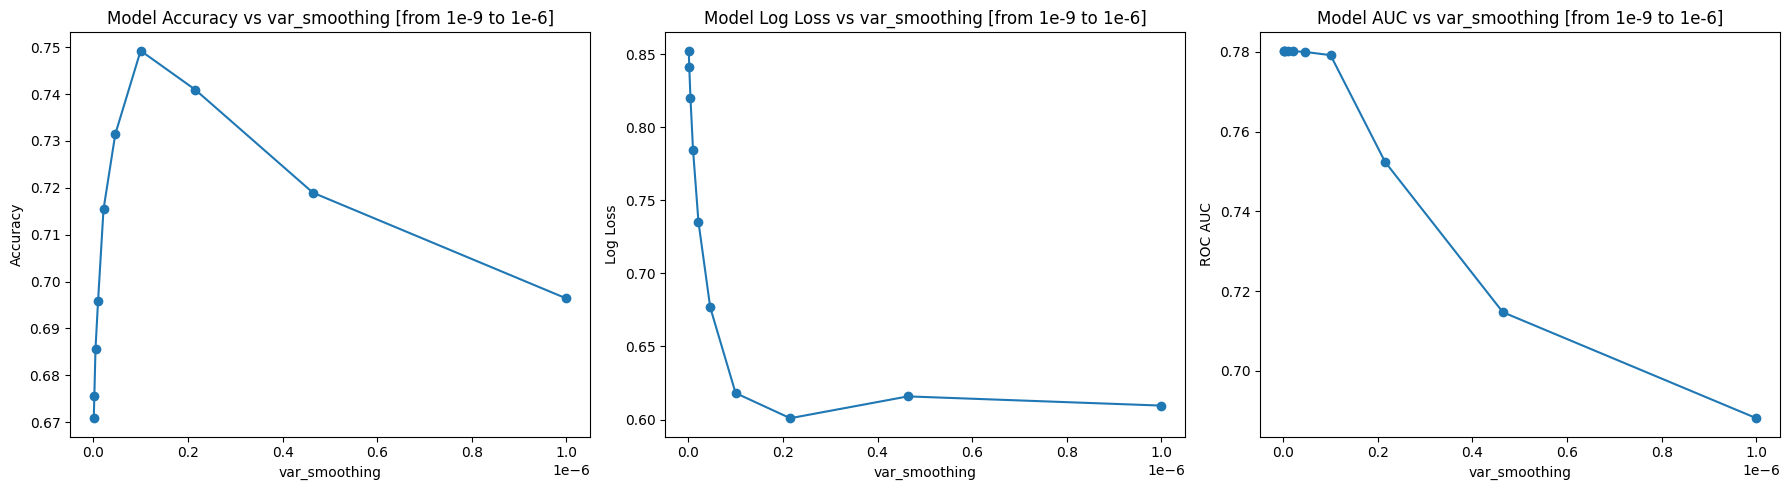

In [239]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(var_smoothing_list, accuracies, marker='o')
plt.title("Model Accuracy vs var_smoothing [from 1e-9 to 1e-6]")
plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")

plt.subplot(1, 3, 2)
plt.plot(var_smoothing_list, losses, marker='o')
plt.title("Model Log Loss vs var_smoothing [from 1e-9 to 1e-6]")
plt.xlabel("var_smoothing")
plt.ylabel("Log Loss")

plt.subplot(1, 3, 3)
plt.plot(var_smoothing_list, aucs, marker='o')
plt.title("Model AUC vs var_smoothing [from 1e-9 to 1e-6]")
plt.xlabel("var_smoothing")
plt.ylabel("ROC AUC")

plt.tight_layout()
plt.show()